<a href="https://colab.research.google.com/github/zhong-david/zhong-david.github.io/blob/master/Lab_3_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
####### INITIAL METHODS ##########
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

#Define function that will let us plot decision regions
def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

    # highlight test samples
    if test_idx:
        # plot all samples
        X_test, y_test = X[test_idx, :], y[test_idx]

        plt.scatter(X_test[:, 0],
                    X_test[:, 1],
                    c='',
                    edgecolor='black',
                    alpha=1.0,
                    linewidth=1,
                    marker='o',
                    s=100, 
                    label='test set')

Lab Report 3:

1)

a.

In [77]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import numpy as np

X, y = make_moons(n_samples=10000,noise=0.3, random_state=42)

TypeError: ignored

b.

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

c.

In [79]:
params = {'max_leaf_nodes': list(range(0, 100)), 'min_samples_split': [1, 2, 3, 4, 5], 'max_depth': [1, 2, 3, 4]} # create list of params for grid search cv
tree1 = GridSearchCV(DecisionTreeClassifier(criterion='entropy', random_state=1), params, n_jobs=-1, verbose=1, cv=5) # create list of params for grid search cv. do 5 fold CV

tree1.fit(X_train, y_train) #fit the model from grid-search CV

Fitting 5 folds for each of 2000 candidates, totalling 10000 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done 646 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done 5446 tasks      | elapsed:   25.4s
[Parallel(n_jobs=-1)]: Done 10000 out of 10000 | elapsed:  1.0min finished


GridSearchCV(cv=5, error_score=nan,
             estimator=DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None,
                                              criterion='entropy',
                                              max_depth=None, max_features=None,
                                              max_leaf_nodes=None,
                                              min_impurity_decrease=0.0,
                                              min_impurity_split=None,
                                              min_samples_leaf=1,
                                              min_samples_split=2,
                                              min_weight_fraction_leaf=0.0,
                                              presort='deprecated',
                                              random_state=1, splitter='best'),
             iid='deprecated', n_jobs=-1,
             param_grid={'max_depth': [1, 2, 3, 4],
                         'max_leaf_nodes': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 

d.

In [80]:
tree1.best_estimator_

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=2, max_features=None, max_leaf_nodes=4,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=1, splitter='best')

e.

In [81]:
y_pred = tree1.predict(X_test)
y_train_pred = tree1.predict(X_train)
print("Training:")
print(accuracy_score(y_train, y_train_pred))
print("Test:")
accuracy_score(y_test, y_pred) #print accuracy score

Training:
0.8945
Test:


0.892

f.

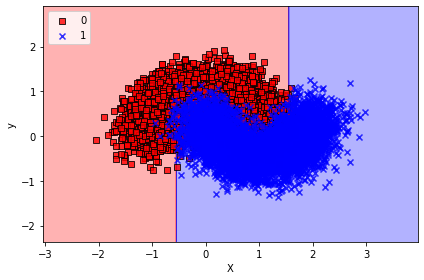

In [82]:
from sklearn.metrics import accuracy_score
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=tree1)
plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

2)

a.

In [71]:
from sklearn.ensemble import RandomForestClassifier
params = {'criterion': ['gini', 'entropy'], 'n_estimators': [10, 50, 100, 200, 500], 'max_depth': [1, 2, 3, 4]} # create list of params for grid search cv
forest1 = GridSearchCV(RandomForestClassifier(), params, n_jobs=-1, verbose=1, cv=5) # create list of params for grid search cv. do 5 fold CV
forest1.fit(X_train, y_train)
forest1.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:  1.8min finished


RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=4, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=10,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

b.

In [74]:
y_pred = forest1.predict(X_test)
y_train_pred = forest1.predict(X_train)
print("Training:")
print(accuracy_score(y_train, y_train_pred))
print("Test:")
accuracy_score(y_test, y_pred) #print accuracy score

Training:
0.896
Test:


0.91

c.

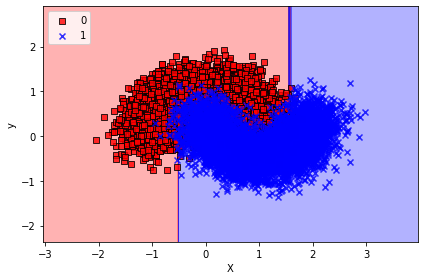

In [76]:
X_combined = np.vstack((X_train, X_test))
y_combined = np.hstack((y_train, y_test))
plot_decision_regions(X_combined, y_combined, 
                      classifier=forest1)
plt.xlabel('X')
plt.ylabel('y')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

3)

Maximum number of principal components: 13

4)

Training:
0.9838709677419355

Test:
0.9259259259259259

5)

Training:
0.9919354838709677

Test:
0.9259259259259259

6)

a.

In [86]:
#Here we read in the MNIST dataset.
#Note MNIST dataset has 10 classes -- images 0,1,2,3,4,5,6,7,8,9, and is described by 784 features. [28 x 28 pixels]
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

#Dataset requires some sorting to keep organized.
def sort_by_target(mnist):
    reorder_train = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[:60000])]))[:, 1]
    reorder_test = np.array(sorted([(target, i) for i, target in enumerate(mnist.target[60000:])]))[:, 1]
    mnist.data[:60000] = mnist.data[reorder_train]
    mnist.target[:60000] = mnist.target[reorder_train]
    mnist.data[60000:] = mnist.data[reorder_test + 60000]
    mnist.target[60000:] = mnist.target[reorder_test + 60000]
    
try:
    from sklearn.datasets import fetch_openml
    mnist = fetch_openml('mnist_784', version=1, cache=True)
    mnist.target = mnist.target.astype(np.int8) # fetch_openml() returns targets as strings
    sort_by_target(mnist) # fetch_openml() returns an unsorted dataset
except ImportError:
    from sklearn.datasets import fetch_mldata
    mnist = fetch_mldata('MNIST original')
mnist["data"], mnist["target"]


#dataset contains 784 features
X, y = mnist["data"], mnist["target"]
X.shape

(70000, 784)

b.

(50,2) means 

In [110]:
from sklearn.neural_network import MLPClassifier
X_train = mnist['data'][:60000]
y_train = mnist['target'][:60000]
X_test = mnist['data'][60000:]
y_test = mnist['target'][60000:]
mlp1 = MLPClassifier(hidden_layer_sizes=(10,1), activation='relu', solver= 'adam', max_iter=100, verbose=True)
mlp2 = MLPClassifier(hidden_layer_sizes=(100,1), activation='relu', solver= 'adam', max_iter=100, verbose=True)
mlp3 = MLPClassifier(hidden_layer_sizes=(50,2), activation='relu', solver= 'adam', max_iter=100, verbose=True)
mlp1.fit(X_train, y_train)
mlp2.fit(X_train, y_train)
mlp3.fit(X_train, y_train)

Iteration 1, loss = 2.15765520
Iteration 2, loss = 2.06327529
Iteration 3, loss = 1.98272578
Iteration 4, loss = 1.92716340
Iteration 5, loss = 1.86378948
Iteration 6, loss = 1.76401952
Iteration 7, loss = 1.70432523
Iteration 8, loss = 1.65324338
Iteration 9, loss = 1.61028767
Iteration 10, loss = 1.54150557
Iteration 11, loss = 1.49477838
Iteration 12, loss = 1.46372783
Iteration 13, loss = 1.43478954
Iteration 14, loss = 1.41811882
Iteration 15, loss = 1.40053101
Iteration 16, loss = 1.38446669
Iteration 17, loss = 1.37656450
Iteration 18, loss = 1.36230516
Iteration 19, loss = 1.35489203
Iteration 20, loss = 1.34885347
Iteration 21, loss = 1.33576435
Iteration 22, loss = 1.32917756
Iteration 23, loss = 1.32156024
Iteration 24, loss = 1.31453077
Iteration 25, loss = 1.31275252
Iteration 26, loss = 1.30616185
Iteration 27, loss = 1.29553838
Iteration 28, loss = 1.29442643
Iteration 29, loss = 1.28682248
Iteration 30, loss = 1.28672773
Iteration 31, loss = 1.27630214
Iteration 32, los

/usr/local/lib/python3.7/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:571: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  % self.max_iter, ConvergenceWarning)


Iteration 1, loss = 2.82270790
Iteration 2, loss = 2.31589653
Iteration 3, loss = 2.30487953
Iteration 4, loss = 2.30201392
Iteration 5, loss = 2.30140132
Iteration 6, loss = 2.30128411
Iteration 7, loss = 2.30127141
Iteration 8, loss = 2.30126865
Iteration 9, loss = 2.30126873
Iteration 10, loss = 2.30127446
Iteration 11, loss = 2.30126924
Iteration 12, loss = 2.30127545
Iteration 13, loss = 2.30126246
Iteration 14, loss = 2.30126954
Iteration 15, loss = 2.30127039
Iteration 16, loss = 2.30128080
Iteration 17, loss = 2.30127060
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
Iteration 1, loss = 3.35516140
Iteration 2, loss = 2.32068696
Iteration 3, loss = 2.30636894
Iteration 4, loss = 2.30238782
Iteration 5, loss = 2.30145920
Iteration 6, loss = 2.30127691
Iteration 7, loss = 2.30126115
Iteration 8, loss = 2.30124525
Iteration 9, loss = 2.30126040
Iteration 10, loss = 2.30127348
Iteration 11, loss = 2.30126504
Iteration 12, loss = 2.30125820


MLPClassifier(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(50, 2), learning_rate='constant',
              learning_rate_init=0.001, max_fun=15000, max_iter=100,
              momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
              power_t=0.5, random_state=None, shuffle=True, solver='adam',
              tol=0.0001, validation_fraction=0.1, verbose=True,
              warm_start=False)

c.

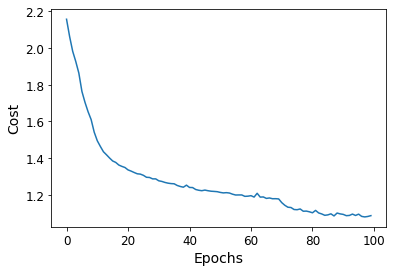

In [117]:
plt.plot(mlp1.loss_curve_)

plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.show()

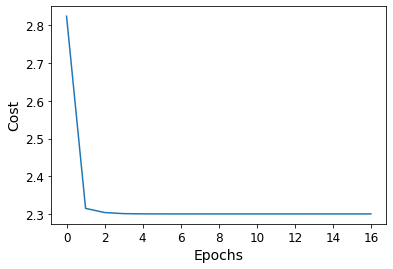

In [118]:
plt.plot(mlp2.loss_curve_)

plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.show()

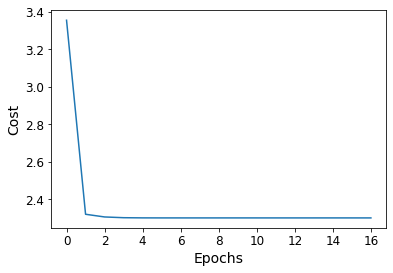

In [116]:
plt.plot(mlp3.loss_curve_)

plt.ylabel('Cost')
plt.xlabel('Epochs')
plt.show()

d.

In [124]:
#test model on test set
y_test_pred = mlp1.predict(X_test) 

#print accuracy on test set from scratch
acc = (np.sum(y_test == y_test_pred)
       .astype(np.float) / X_test.shape[0])
print('mlp1 (10,1):')
print('Test accuracy: %.2f%%' % (acc * 100))

#reprint accuracy score on test set using sklearn
from sklearn.metrics import accuracy_score
acc1 = accuracy_score(y_test, y_test_pred)
print('Test accuracy: %.2f%%' % (acc1 * 100), '\n')

#test model on test set
y_test_pred = mlp2.predict(X_test) 

#print accuracy on test set from scratch
acc = (np.sum(y_test == y_test_pred)
       .astype(np.float) / X_test.shape[0])
print('mlp2 (100,1):')
print('Test accuracy: %.2f%%' % (acc * 100))

#reprint accuracy score on test set using sklearn
from sklearn.metrics import accuracy_score
acc1 = accuracy_score(y_test, y_test_pred)
print('Test accuracy: %.2f%%' % (acc1 * 100), '\n')

#test model on test set
y_test_pred = mlp3.predict(X_test) 

#print accuracy on test set from scratch
acc = (np.sum(y_test == y_test_pred)
       .astype(np.float) / X_test.shape[0])
print('mlp3 (50,2):')
print('Test accuracy: %.2f%%' % (acc * 100))

#reprint accuracy score on test set using sklearn
from sklearn.metrics import accuracy_score
acc1 = accuracy_score(y_test, y_test_pred)
print('Test accuracy: %.2f%%' % (acc1 * 100), '\n')

mlp1 (10,1):
Test accuracy: 52.87%
Test accuracy: 52.87% 

mlp2 (100,1):
Test accuracy: 11.35%
Test accuracy: 11.35% 

mlp3 (50,2):
Test accuracy: 11.35%
Test accuracy: 11.35% 

